In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#  data path 
DATA_PATH = '../data/raw/'  # Put your OULAD files here

print('Libraries loaded successfully')

Libraries loaded successfully
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


## Step 1 — Load All Files

In [3]:
# Load all OULAD files
student_info = pd.read_csv(DATA_PATH + 'studentInfo.csv')
student_ass  = pd.read_csv(DATA_PATH + 'studentAssessment.csv')
assessments  = pd.read_csv(DATA_PATH + 'assessments.csv')
registration = pd.read_csv(DATA_PATH + 'studentRegistration.csv')
vle          = pd.read_csv(DATA_PATH + 'vle.csv')

print('=== FILE SIZES ===')
print(f'studentInfo:       {student_info.shape}')
print(f'studentAssessment: {student_ass.shape}')
print(f'assessments:       {assessments.shape}')
print(f'studentRegistration: {registration.shape}')
print(f'vle:               {vle.shape}')

=== FILE SIZES ===
studentInfo:       (32593, 12)
studentAssessment: (173912, 5)
assessments:       (206, 6)
studentRegistration: (32593, 5)
vle:               (6364, 6)


## Step 2 - Understand studentInfo 

In [5]:
print('=== STUDENT INFO COLUMNS ===')
print(student_info.columns.tolist())
print()
print('=== FIRST 3 ROWS ===')
student_info.head(3)

=== STUDENT INFO COLUMNS ===
['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']

=== FIRST 3 ROWS ===


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn


=== FINAL RESULT DISTRIBUTION ===
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

 BINARY LABEL 
label
1    17208
0    15385
Name: count, dtype: int64
At-risk rate: 52.8%


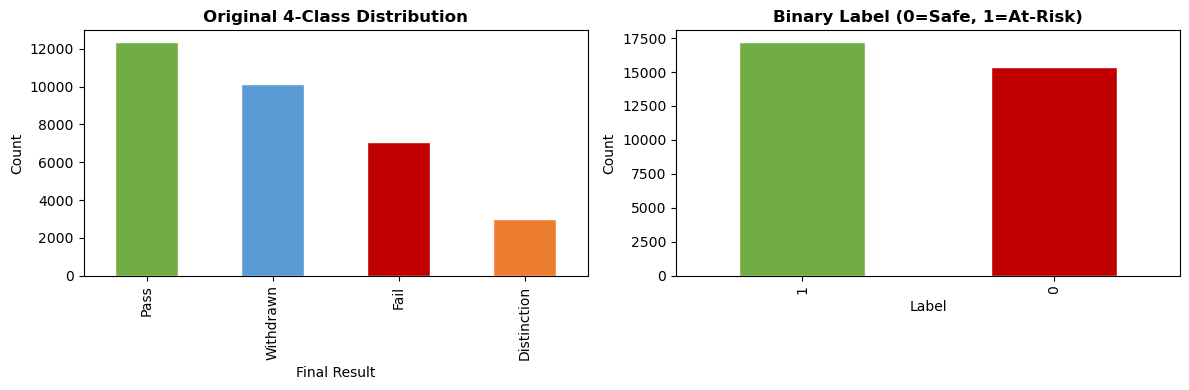

Chart saved.


In [11]:
print('=== FINAL RESULT DISTRIBUTION ===')
print(student_info['final_result'].value_counts())
print()

# Create binary label
# Pass + Distinction = 0 (NOT at risk)
# Fail + Withdrawn   = 1 (AT RISK)
student_info['label'] = student_info['final_result'].apply(
    lambda x: 0 if x in ['Pass', 'Distinction'] else 1)

print(' BINARY LABEL ')
print(student_info['label'].value_counts())
print(f'At-risk rate: {student_info["label"].mean()*100:.1f}%')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

student_info['final_result'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#70AD47','#5B9BD5','#C00000','#ED7D31'],
    edgecolor='white')
axes[0].set_title('Original 4-Class Distribution', fontweight='bold')
axes[0].set_xlabel('Final Result')
axes[0].set_ylabel('Count')

student_info['label'].value_counts().plot(
    kind='bar', ax=axes[1], color=['#70AD47','#C00000'],
    edgecolor='white')
axes[1].set_title('Binary Label (0=Safe, 1=At-Risk)', fontweight='bold')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Count')

plt.tight_layout()
import os
os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/label_distribution.png', dpi=120)
plt.show()
print('Chart saved.')

## Step 3 - Understand Assessment Data

In [12]:
print('=== ASSESSMENT TYPES ===')
print(assessments['assessment_type'].value_counts())
print()
print('TMA = Tutor Marked Assignment (regular)')
print('CMA = Computer Marked Assignment (quiz)')
print('Exam = Final exam')
print()
print('=== ASSESSMENT DATE RANGE ===')
print(f'Earliest: day {assessments["date"].min()}')
print(f'Latest:   day {assessments["date"].max()}')
print(f'In weeks: week {int(assessments["date"].min()/7)+1} to week {int(assessments["date"].max()/7)+1}')
print()
print('=== MISSING SCORES ===')
print(f'Missing: {student_ass["score"].isna().sum()} rows')
print('These are students who did not submit')

=== ASSESSMENT TYPES ===
assessment_type
TMA     106
CMA      76
Exam     24
Name: count, dtype: int64

TMA = Tutor Marked Assignment (regular)
CMA = Computer Marked Assignment (quiz)
Exam = Final exam

=== ASSESSMENT DATE RANGE ===
Earliest: day 12.0
Latest:   day 261.0
In weeks: week 2 to week 38

=== MISSING SCORES ===
Missing: 173 rows
These are students who did not submit


In [13]:
# Merge assessments to get weeks
merged = student_ass.merge(
    assessments[['id_assessment','date','assessment_type','weight']],
    on='id_assessment', how='left')
merged = merged.merge(
    student_info[['id_student','code_module','code_presentation','final_result','label']],
    on='id_student', how='left')

# Remove rows with no date (exam submissions logged differently)
merged = merged.dropna(subset=['date'])
merged['week'] = (merged['date'] / 7).astype(int) + 1

print('=== AFTER MERGING ===')
print(f'Total records: {len(merged)}')
print(f'Week range: {merged["week"].min()} to {merged["week"].max()}')
print()

# Per student weekly data
per_student = merged.groupby('id_student')['week'].nunique()
print('=== WEEKS OF DATA PER STUDENT ===')
print(per_student.describe().round(2))
print()
print(f'Students with 4+ weeks: {(per_student >= 4).sum()}')
print(f'Students with 8+ weeks: {(per_student >= 8).sum()}')

=== AFTER MERGING ===
Total records: 203301
Week range: 2 to 38

=== WEEKS OF DATA PER STUDENT ===
count    23369.00
mean         5.17
std          2.45
min          1.00
25%          4.00
50%          5.00
75%          7.00
max         18.00
Name: week, dtype: float64

Students with 4+ weeks: 18187
Students with 8+ weeks: 2332


## Step 4 - Check Missing Values and Data Quality

In [14]:
print('=== MISSING VALUES IN studentInfo ===')
print(student_info.isnull().sum())
print()
print('=== MISSING VALUES IN studentAssessment ===')
print(student_ass.isnull().sum())
print()

# IMD band has missing values - check
print('=== IMD_BAND distribution ===')
print(student_info['imd_band'].value_counts(dropna=False))

=== MISSING VALUES IN studentInfo ===
code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
label                      0
dtype: int64

=== MISSING VALUES IN studentAssessment ===
id_assessment       0
id_student          0
date_submitted      0
is_banked           0
score             173
dtype: int64

=== IMD_BAND distribution ===
imd_band
20-30%     3654
30-40%     3539
10-20      3516
0-10%      3311
40-50%     3256
50-60%     3124
60-70%     2905
70-80%     2879
80-90%     2762
90-100%    2536
NaN        1111
Name: count, dtype: int64


## Step 5 — Dataset Summary

In [15]:
print('=' * 55)
print('OULAD DATASET SUMMARY FOR R26-IT-059')
print('=' * 55)
print(f'Total students:          {len(student_info):,}')
print(f'Total assessment records:{len(student_ass):,}')
print(f'Modules:                 {student_info["code_module"].nunique()}')
print(f'Presentations:           {student_info["code_presentation"].nunique()}')
print()
print('LABEL DISTRIBUTION:')
for result, count in student_info['final_result'].value_counts().items():
    pct = count/len(student_info)*100
    print(f'  {result:<12}: {count:>6,} ({pct:.1f}%)')
print()
print(f'AT-RISK (Fail+Withdrawn): {student_info["label"].sum():,} ({student_info["label"].mean()*100:.1f}%)')
print(f'SAFE (Pass+Distinction):  {(student_info["label"]==0).sum():,} ({(student_info["label"]==0).mean()*100:.1f}%)')
print()
print('DATA QUALITY:')
print(f'  Missing scores:  {student_ass["score"].isna().sum()} rows')
print(f'  Missing IMD:     {student_info["imd_band"].isna().sum()} students')
print('=' * 55)
print('NOTE: studentVle.csv is needed for login/click')
print('features F1 and F2. Download the full OULAD')
print('from analytics.open.ac.uk/datasets')

OULAD DATASET SUMMARY FOR R26-IT-059
Total students:          32,593
Total assessment records:173,912
Modules:                 7
Presentations:           4

LABEL DISTRIBUTION:
  Pass        : 12,361 (37.9%)
  Withdrawn   : 10,156 (31.2%)
  Fail        :  7,052 (21.6%)
  Distinction :  3,024 (9.3%)

AT-RISK (Fail+Withdrawn): 17,208 (52.8%)
SAFE (Pass+Distinction):  15,385 (47.2%)

DATA QUALITY:
  Missing scores:  173 rows
  Missing IMD:     1111 students
NOTE: studentVle.csv is needed for login/click
features F1 and F2. Download the full OULAD
from analytics.open.ac.uk/datasets
